# 04 — Statistical Analysis & Outcomes Exploration

## Overview

This notebook represents the final analytical stage of the **Higher Education Outcomes Analysis** project. 

> **Data context:** This notebook runs on the public synthetic analytical dataset for 2024 C1. Its purpose is to reproduce the analytical workflow and broadly similar patterns from the original institutional analysis. Because the outcomes are synthetic, the descriptive statistics and inferential conclusions below are demo results and may differ from the reviewed institutional results in the technical report.

Building upon the processed demo dataset generated in the previous pipeline stages, this notebook performs exploratory and inferential analysis of section-level completion rates. The primary goal is to describe patterns and evaluate associations between completion and course-section characteristics.

Instead of an exhaustive traversal of every variable, this analysis is structured as an investigation driven by specific research questions:

1. **What is the baseline distribution of academic outcomes in the public synthetic analytical dataset?**
2. **How do section-level completion rates differ across delivery modes (On-site, Online, Hybrid)?**
3. **Does class shift appear to be associated with section-level completion?**
4. **Do mean completion rates differ across academic programs?**
5. **What descriptive pattern appears when shift and delivery mode are examined together?**

Descriptive statistics, visualizations, confidence intervals, and hypothesis tests are interpreted as course-section evidence from one synthetic representation of one academic term. They do not establish student-level or causal effects.


In [1]:
from notebook_utils import ensure_repo_root

# Establish the repository root as the working directory for this notebook
ensure_repo_root()

WindowsPath('C:/Github/higher-education-outcomes-analysis')

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import pingouin as pg
from scipy import stats
import statsmodels.api as sm
import matplotlib.pyplot as plt
from statsmodels.formula.api import ols

from src.reporting import (
    format_games_howell,
    format_residual_normality,
    format_welch_anova,
)
from src.utils.data_utils import load_data, set_pandas_display_options

# Set plotting style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10
})

# Set pandas display options for better readability
set_pandas_display_options()
pd.set_option("display.float_format", "{:.4f}".format)

## Data Loading and Verification

We load the public synthetic processed dataset produced by the `03_metric_construction.ipynb` stage. This dataset includes canonical categorizations, integrated operational metadata, and derived analytical metrics (e.g., `completion_rate`, `dropout_rate`).

In [3]:
# Load the processed dataset
data = load_data("demo processed")

# Verify dimensions
print(f"Dataset dimensions: {data.shape[0]} rows, {data.shape[1]} columns")

# Verify absence of missing values in key analytical variables
assert data['completion_rate'].isna().sum() == 0, "Missing values detected in completion_rate."
assert data['delivery_mode'].isna().sum() == 0, "Missing values detected in delivery_mode."

# Preview the data
display(data.head())

Dataset dimensions: 297 rows, 29 columns


,course_name,section,total_enrollment,dropout_count,insufficient_count,free_status_count,promoted_completion_count,regular_completion_count,course_code,program_code,workload,shift,weekday,schedule_time,delivery_mode,campus,program_name,completion_count,attrition_count,adverse_outcomes_count,dropout_rate,insufficient_rate,free_status_rate,promoted_completion_rate,regular_completion_rate,completion_rate,attrition_rate,adverse_outcomes_rate,excellence_ratio
0,COURSE 090,1,110,5,4,4,43,54,CRS_090,PRG_013,6,night,thursday,19 a 23,online,CAMPUS_006,Program M,97,9,13,0.0455,0.0364,0.0364,0.3909,0.4909,0.8818,0.0818,0.1182,0.4433
1,COURSE 046,1,98,13,8,7,34,36,CRS_046,PRG_002,6,night,tuesday,18 a 22,online,CAMPUS_006,Program B,70,20,28,0.1327,0.0816,0.0714,0.3469,0.3673,0.7143,0.2041,0.2857,0.4857
2,COURSE 046,2,96,21,24,8,19,24,CRS_046,PRG_013,6,night,tuesday,18 a 22,online,CAMPUS_006,Program M,43,29,53,0.2188,0.2500,0.0833,0.1979,0.2500,0.4479,0.3021,0.5521,0.4419
3,COURSE 046,3,112,10,14,10,25,53,CRS_046,PRG_002,6,night,wednesday,18 a 22,online,CAMPUS_006,Program B,78,20,34,0.0893,0.1250,0.0893,0.2232,0.4732,0.6964,0.1786,0.3036,0.3205
4,COURSE 046,4,106,25,29,7,20,25,CRS_046,PRG_013,6,afternoon,thursday,14 a 18,online,CAMPUS_006,Program M,45,32,61,0.2358,0.2736,0.0660,0.1887,0.2358,0.4245,0.3019,0.5755,0.4444


## 1. What is the baseline distribution of academic outcomes?

Before comparing specific groups, we establish the baseline distribution of academic outcomes across the 297 course sections in the public synthetic analytical dataset. Its center and dispersion provide context for the subsequent group comparisons.

We will focus on the `completion_rate`, defined as the sum of promoted and regular completions divided by total enrollment.

### Exploratory Analysis

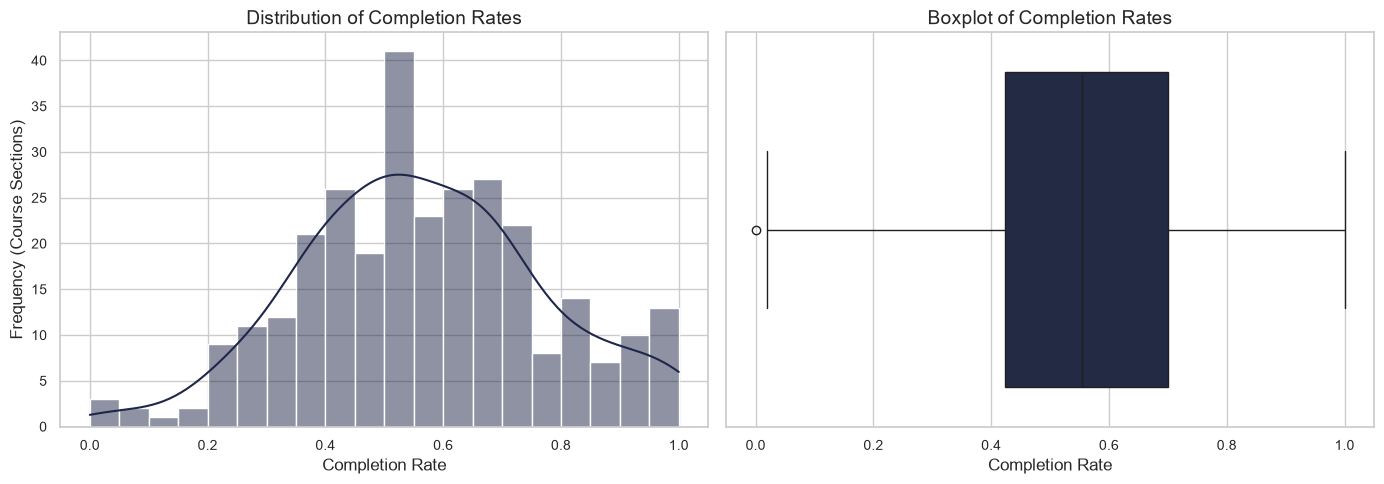

In [4]:
# Distribution of Completion Rates
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Histogram and KDE
sns.histplot(data=data, x='completion_rate', bins=20, kde=True, ax=ax[0], color='#1E2749')
ax[0].set_title('Distribution of Completion Rates')
ax[0].set_xlabel('Completion Rate')
ax[0].set_ylabel('Frequency (Course Sections)')

# Boxplot
sns.boxplot(data=data, x='completion_rate', ax=ax[1], color='#1E2749')
ax[1].set_title('Boxplot of Completion Rates')
ax[1].set_xlabel('Completion Rate')

plt.tight_layout()
plt.show()

Although completion rate is bounded between 0 and 1, the sample size (n = 297) is sufficiently large for the sampling distribution of the mean to be well approximated by the Central Limit Theorem. Therefore, confidence intervals for the mean are computed using the Student's t distribution.

### Descriptive Statistics and Confidence Intervals

In [5]:
# Descriptive statistics for completion rate
completion_stats = data['completion_rate'].agg([
    'count', 'mean', 'median', 'std', 'var', 'min', 'max', 'skew'
]).round(4)

# 95% Confidence Interval for the mean completion rate
mean = completion_stats['mean']
sem = stats.sem(data['completion_rate'])
ci_lower, ci_upper = stats.t.interval(0.95, len(data)-1, loc=mean, scale=sem)

print("--- Descriptive Statistics: Completion Rate ---")
print(completion_stats)
print(f"\n95% CI for the Mean: [{ci_lower:.4f}, {ci_upper:.4f}]")

--- Descriptive Statistics: Completion Rate ---
count    297.0000
mean       0.5658
median     0.5536
std        0.2075
var        0.0431
min        0.0000
max        1.0000
skew       0.0510
Name: completion_rate, dtype: float64

95% CI for the Mean: [0.5421, 0.5895]


### Interpretation

- **What does the result show?** Across the 297 demo course sections, the mean completion rate is 56.58% and the median is 55.36%. The distribution is approximately symmetric (skewness = 0.0510), with a standard deviation of 20.75 percentage points and values spanning 0% to 100%.
- **How precise is the estimate?** The 95% confidence interval for the demo mean is [0.5421, 0.5895]. This interval quantifies uncertainty around the mean of the public synthetic analytical dataset; it is not an estimate of a public institutional parameter.
- **Practical relevance:** The 56.58% mean provides a descriptive baseline for the grouped analyses. The observed section-to-section dispersion motivates examining delivery mode, shift, and academic program, but does not by itself show that those factors account for the variation.

---

## 2. How do section-level completion rates differ across delivery modes?

We ask whether mean section-level completion rates in the public synthetic analytical dataset differ across delivery modes (On-site, Online, and Hybrid).

### Exploratory Analysis

,count,mean,median,std
delivery_mode,,,,
online,44,0.5861,0.5497,0.1767
on-site,197,0.5848,0.5882,0.2071
hybrid,56,0.4827,0.4732,0.2142


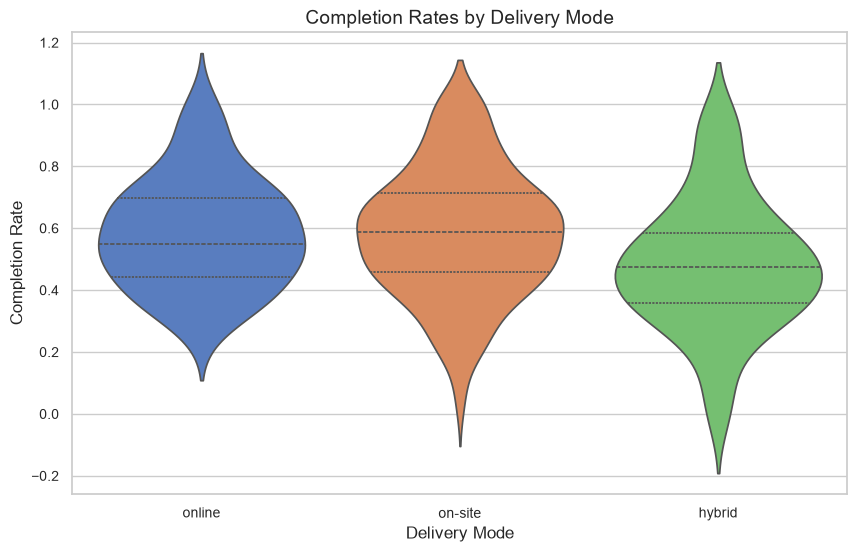

In [6]:
# Calculate summary statistics by delivery mode
delivery_stats = data.groupby('delivery_mode')['completion_rate'].agg([
    'count', 'mean', 'median', 'std'
]).sort_values('mean', ascending=False)

display(delivery_stats)

# Visualizing distributions by delivery mode
fig, ax = plt.subplots(figsize=(10, 6))
sns.violinplot(
    data=data, 
    x='delivery_mode', 
    y='completion_rate', 
    order=delivery_stats.index,
    hue="delivery_mode",
    palette="muted",
    inner='quartile',
    ax=ax
)
ax.set_title('Completion Rates by Delivery Mode')
ax.set_xlabel('Delivery Mode')
ax.set_ylabel('Completion Rate')
plt.show()

### Statistical Inference

We first use Shapiro-Wilk as a residual diagnostic. Because group sizes are unbalanced and equal variances are not assumed, we apply Welch's ANOVA. A significant omnibus result is followed by Games-Howell comparisons to identify statistically supported group pairs.

**Null Hypothesis ($H_0$):** The mean completion rate is equal across all delivery modes.  
**Alternative Hypothesis ($H_1$):** At least one delivery mode has a different mean completion rate.

In [7]:
# Residual normality assumption
model_del = ols('completion_rate ~ C(delivery_mode)', data=data).fit()
res_norm_del = pg.normality(model_del.resid)
print("Residual Normality (Shapiro-Wilk):")
display(format_residual_normality(res_norm_del.assign(Source='delivery_mode')))

# Welch's ANOVA
aov_del = pg.welch_anova(dv='completion_rate', between='delivery_mode', data=data)
print("\nWelch's ANOVA:")
display(format_welch_anova(aov_del))

# Games-Howell Post-Hoc Test
gh_del = pg.pairwise_gameshowell(dv='completion_rate', between='delivery_mode', data=data)
print("\nGames-Howell Post-Hoc Test:")
display(format_games_howell(gh_del, 'delivery_mode'))

Residual Normality (Shapiro-Wilk):


,W,pval,normal
0,0.9907,0.0558,True



Welch's ANOVA:


,Source,ddof1,ddof2,F,p_unc,np2
0,delivery_mode,2,94.2283,5.2821,0.0067,0.0374



Games-Howell Post-Hoc Test:


,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges
0,hybrid,on-site,0.4827,0.5848,-0.1021,0.0322,-3.1712,86.3834,0.0059,-0.4880
1,hybrid,online,0.4827,0.5861,-0.1034,0.0391,-2.6434,97.7481,0.0257,-0.5164
2,on-site,online,0.5848,0.5861,-0.0012,0.0304,-0.0404,71.9501,0.9991,-0.0061


### Interpretation

- **What does the result show?** Online and On-site sections have very similar mean completion rates (58.61% and 58.48%, respectively), while Hybrid sections have a lower mean (48.27%). The residual diagnostic does not indicate a statistically significant departure from normality at $\alpha = 0.05$ (Shapiro-Wilk $W=0.9907$, $p=0.0558$); this diagnostic is interpreted alongside the distribution and does not by itself validate the full analysis.
- **How strong is the evidence?** Welch's ANOVA supports an overall difference across delivery modes, $F(2, 94.23)=5.28$, $p=0.0067$. Games-Howell comparisons show lower mean completion for Hybrid than On-site ($p=0.0059$) and Hybrid than Online ($p=0.0257$). The Online–On-site comparison is not statistically significant ($p=0.9991$).
- **How large is the observed effect?** Partial eta-squared is 0.037, a small estimated effect. Delivery mode is statistically associated with completion in the demo data, but it is not a dominant source of section-level variation.
- **Practical relevance:** The demo analysis supports a distinction involving Hybrid sections. Online and On-site show very similar means and no statistically significant pairwise difference, but this non-significant result is not evidence that the two delivery modes are equivalent. The observational analysis does not identify why Hybrid sections have a lower mean.

---

## 3. Does class shift appear to be associated with section-level completion?

We investigate whether mean section-level completion rates in the public synthetic analytical dataset differ across Morning, Afternoon, and Night shifts. Shift assignment may be associated with unmeasured section or student characteristics, so observed differences are not interpreted causally.

### Exploratory Analysis

,count,mean,median,std
shift,,,,
night,175,0.6018,0.6111,0.2072
morning,72,0.5208,0.5246,0.2291
afternoon,50,0.5043,0.5000,0.1421


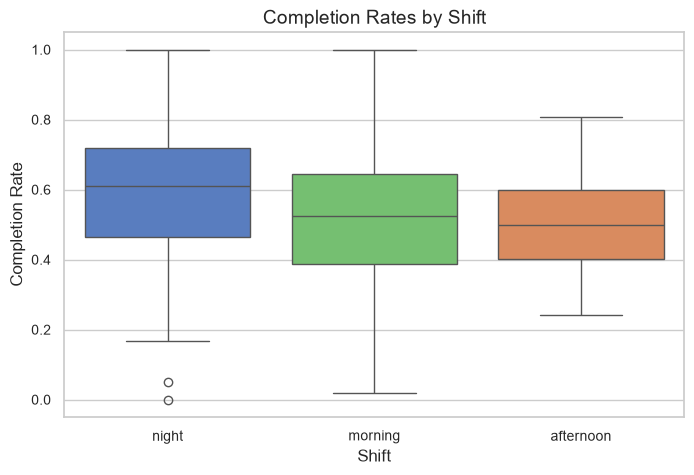

In [8]:
shift_stats = data.groupby('shift')['completion_rate'].agg([
    'count', 'mean', 'median', 'std'
]).sort_values('mean', ascending=False).round(4)

display(shift_stats)

# Visualizing distributions by shift
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(
    data=data, 
    x='shift', 
    y='completion_rate', 
    order=shift_stats.index,
    hue="shift",
    palette='muted',
    ax=ax
)
ax.set_title('Completion Rates by Shift')
ax.set_xlabel('Shift')
ax.set_ylabel('Completion Rate')
plt.show()

### Statistical Inference

We use Shapiro-Wilk as a residual diagnostic and apply Welch's ANOVA because group sizes are unbalanced and equal variances are not assumed. A significant omnibus result is followed by Games-Howell comparisons.

**Null Hypothesis ($H_0$):** The mean completion rate is equal across all shifts.  
**Alternative Hypothesis ($H_1$):** At least one shift has a different mean completion rate.

In [9]:
# Residual normality assumption
model_shift = ols('completion_rate ~ C(shift)', data=data).fit()
res_norm_shift = pg.normality(model_shift.resid)
print("Residual Normality (Shapiro-Wilk):")
display(format_residual_normality(res_norm_shift.assign(Source='shift')))

# Welch's ANOVA
aov_shift = pg.welch_anova(dv='completion_rate', between='shift', data=data)
print("\nWelch's ANOVA:")
display(format_welch_anova(aov_shift))

# Games-Howell Post-Hoc Test
gh_shift = pg.pairwise_gameshowell(dv='completion_rate', between='shift', data=data)
print("\nGames-Howell Post-Hoc Test:")
display(format_games_howell(gh_shift, 'shift'))

Residual Normality (Shapiro-Wilk):


,W,pval,normal
0,0.9938,0.2628,True



Welch's ANOVA:


,Source,ddof1,ddof2,F,p_unc,np2
0,shift,2,129.2260,8.3954,0.0004,0.0441



Games-Howell Post-Hoc Test:


,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges
0,afternoon,morning,0.5043,0.5208,-0.0166,0.0337,-0.4917,118.6813,0.8754,-0.0830
1,afternoon,night,0.5043,0.6018,-0.0976,0.0255,-3.8295,114.6450,0.0006,-0.4994
2,morning,night,0.5208,0.6018,-0.0810,0.0312,-2.5957,121.1937,0.0284,-0.3779


### Interpretation

- **What does the result show?** Night is the largest shift group ($n=175$) and has the highest mean completion rate (60.18%). Morning and Afternoon have lower means (52.08% and 50.43%, respectively). The residual diagnostic does not indicate a statistically significant departure from normality (Shapiro-Wilk $W=0.9938$, $p=0.2628$); it is one diagnostic rather than confirmation that residuals are normal.
- **How strong is the evidence?** Welch's ANOVA supports an overall difference across shifts, $F(2, 129.23)=8.40$, $p=0.0004$. Games-Howell comparisons show that Night has higher mean completion than Afternoon ($p=0.0006$) and Morning ($p=0.0284$). The Afternoon–Morning comparison is not statistically significant ($p=0.8754$).
- **How large is the observed effect?** Partial eta-squared is 0.044, a small estimated effect, comparable in magnitude to the delivery-mode result.
- **Practical relevance:** The demo data support a section-level association between shift and completion, with Night sections showing the highest mean. The analysis contains no student demographics or formal adjustment for confounding, so explanations involving employment, maturity, motivation, or time management cannot be evaluated here.

---

## 4. Do mean completion rates differ across academic programs?

We evaluate whether the observed section-level mean completion rates differ across academic programs in the public synthetic analytical dataset. Programs with fewer than ten sections are excluded from the inferential comparison.

### Exploratory Analysis

,count,mean,std,sem,ci_lower,ci_upper
program_name,,,,,,
Program K,20,0.6159,0.1743,0.0390,0.5394,0.6923
Program E,31,0.5984,0.2099,0.0377,0.5245,0.6723
Program D,31,0.5943,0.1921,0.0345,0.5266,0.6619
Program L,12,0.5918,0.1720,0.0497,0.4945,0.6892
Program M,44,0.5912,0.2265,0.0341,0.5243,0.6581
Program G,29,0.5860,0.1599,0.0297,0.5279,0.6442
Program C,19,0.5770,0.2142,0.0491,0.4806,0.6733
Program I,28,0.5695,0.2116,0.0400,0.4911,0.6479
Program J,12,0.5615,0.2218,0.0640,0.4359,0.6870


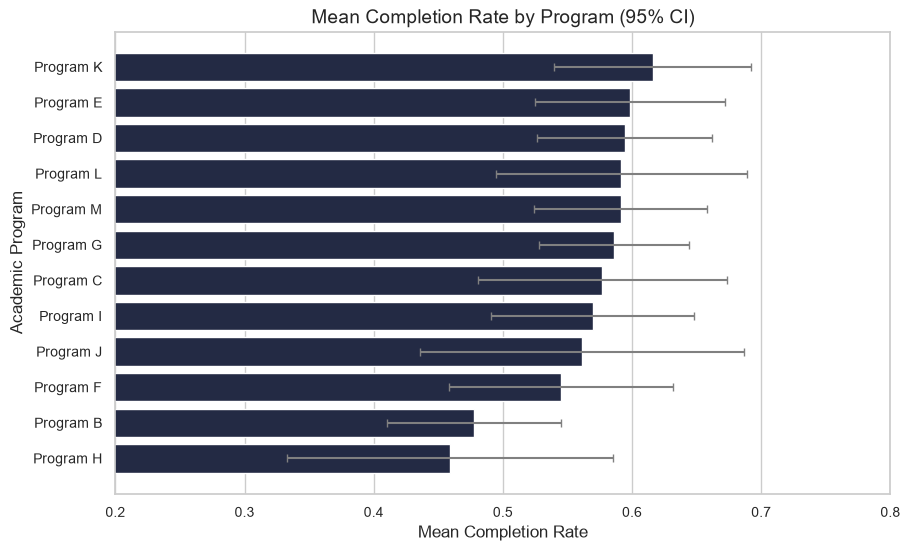

In [10]:
program_stats = data.groupby('program_name')['completion_rate'].agg([
    'count', 'mean', 'std'
]).sort_values('mean', ascending=False)

# Filter out programs with fewer than 10 sections to ensure reliable estimates
program_stats_filtered = program_stats[program_stats['count'] >= 10].copy()

# Calculate 95% CI for the mean of each program
program_stats_filtered['sem'] = program_stats_filtered['std'] / np.sqrt(program_stats_filtered['count'])
program_stats_filtered['ci_lower'] = program_stats_filtered['mean'] - 1.96 * program_stats_filtered['sem']
program_stats_filtered['ci_upper'] = program_stats_filtered['mean'] + 1.96 * program_stats_filtered['sem']

display(program_stats_filtered.round(4))

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=program_stats_filtered.reset_index(),
    x='mean',
    y='program_name',
    color='#1E2749',
    ax=ax,
    capsize=0.1
)

# Overlay confidence intervals
for i, row in enumerate(program_stats_filtered.itertuples()):
    ax.errorbar(x=row.mean, y=i, xerr=1.96*row.sem, color='gray', capsize=3) # type: ignore

ax.set_title('Mean Completion Rate by Program (95% CI)')
ax.set_xlabel('Mean Completion Rate')
ax.set_ylabel('Academic Program')
ax.set_xlim(0.2, 0.8)
plt.show()

### Statistical Inference

We use Shapiro-Wilk as a residual diagnostic and Welch's ANOVA to test for an overall difference across the 12 eligible academic programs. Partial eta-squared is reported descriptively as an estimate of effect magnitude. Games-Howell comparisons are reserved for a statistically significant omnibus result.

**Null Hypothesis ($H_0$):** The mean completion rates are equal across all programs.  
**Alternative Hypothesis ($H_1$):** At least one program has a different mean completion rate.

In [11]:
# Filter programs with at least 10 observations
counts = data['program_name'].value_counts()
valid_progs = counts[counts >= 10].index
data_prog = data[data['program_name'].isin(valid_progs)]

# Residual normality assumption
model_prog = ols('completion_rate ~ C(program_name)', data=data_prog).fit()
res_norm_prog = pg.normality(model_prog.resid)
print("Residual Normality (Shapiro-Wilk):")
display(format_residual_normality(res_norm_prog.assign(Source='program_name')))

# Welch's ANOVA
aov_prog = pg.welch_anova(dv='completion_rate', between='program_name', data=data_prog)
print("\nWelch's ANOVA:")
display(format_welch_anova(aov_prog))

# Note: Since Welch's ANOVA is not significant (p > 0.05), a post-hoc test like Games-Howell is not strictly required.

Residual Normality (Shapiro-Wilk):


,W,pval,normal
0,0.9932,0.2018,True



Welch's ANOVA:


,Source,ddof1,ddof2,F,p_unc,np2
0,program_name,11,92.6396,1.1770,0.3138,0.0439


### Interpretation

- **What does the result show?** Among the 12 eligible programs, observed mean completion rates range descriptively from 61.59% for Program K to 45.92% for Program H. The residual diagnostic does not indicate a statistically significant departure from normality (Shapiro-Wilk $W=0.9932$, $p=0.2018$); it does not establish that residuals are normal.
- **How strong is the evidence?** Welch's ANOVA does not find statistically significant evidence of an overall difference across programs, $F(11, 92.64)=1.18$, $p=0.3138$. The observed mean differences are compatible with sampling variability in this demo dataset. Games-Howell comparisons are therefore not performed.
- **What is the estimated effect size, descriptively?** Partial eta-squared is 0.044, which falls in the project's small-effect category. Because the omnibus test is not statistically significant, this estimate is reported as descriptive magnitude and not as evidence of a program effect.
- **Practical relevance:** The current analysis does not support a clear program-level distinction. Program K and Program H should not be treated as definitively stronger or weaker on the basis of their point estimates, and the overlapping uncertainty intervals are descriptive rather than a substitute for the omnibus test.

---

## 5. What pattern appears across shift and delivery mode? (Descriptive exploration)

Because shift and delivery mode each show statistically supported but small one-factor associations with completion in the demo data, we cross-tabulate their cell means and counts to identify descriptive patterns. The notebook does not fit a factorial model or formally test a shift-by-delivery interaction.

### Exploratory Analysis

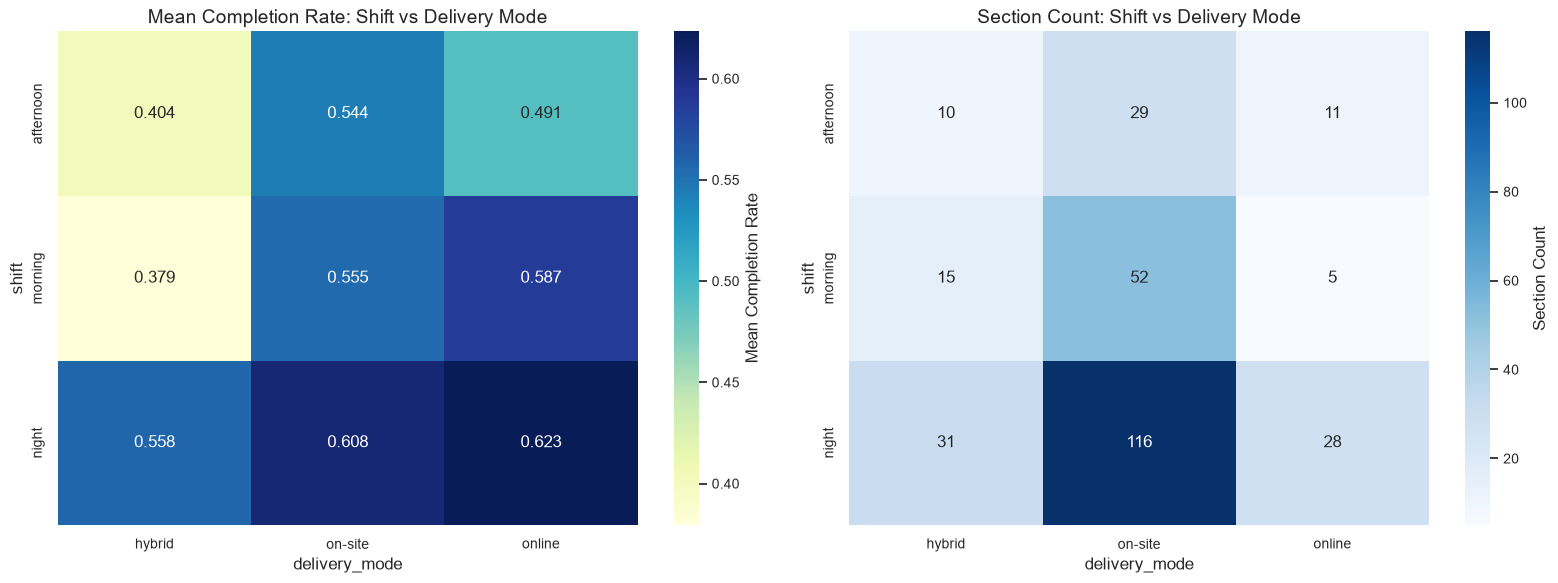

In [12]:
# Create an interaction heatmap
interaction_table = data.pivot_table(
    values='completion_rate', 
    index='shift', 
    columns='delivery_mode', 
    aggfunc='mean'
)

# Also create a count table to understand the volume in each cell
count_table = data.pivot_table(
    values='completion_rate', 
    index='shift', 
    columns='delivery_mode', 
    aggfunc='count'
)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(interaction_table, annot=True, fmt=".3f", cmap="YlGnBu", ax=ax[0], cbar_kws={'label': 'Mean Completion Rate'})
ax[0].set_title('Mean Completion Rate: Shift vs Delivery Mode')

sns.heatmap(count_table, annot=True, fmt="d", cmap="Blues", ax=ax[1], cbar_kws={'label': 'Section Count'})
ax[1].set_title('Section Count: Shift vs Delivery Mode')

plt.tight_layout()
plt.show()

### Interpretation

- **What was observed?** Hybrid mean completion is lower in Morning (37.94%) and Afternoon (40.41%) than in Night (55.81%). Within Night, the Hybrid mean remains below On-site (60.84%) and Online (62.33%). These are descriptive cell means, not pairwise or interaction-test results.
- **Why it matters:** The heatmap suggests that the lower Hybrid mean is more pronounced in the daytime cells. This pattern can guide a future formal interaction analysis, but the current notebook does not establish that shift modifies the association between delivery mode and completion.
- **Limitations:** Cell sizes are unbalanced and some are sparse, including Morning–Online ($n=5$), Afternoon–Hybrid ($n=10$), and Afternoon–Online ($n=11$). The corresponding means are therefore comparatively uncertain, and no scheduling or student-characteristic mechanism can be inferred from this visualization.

---

## Exported report tables

The repository's deterministic report export writes the following tables to `reports/tables/`: `demo_dataset_summary.csv`, `demo_group_descriptive_statistics.csv`, `games_howell_delivery_summary.csv`, `games_howell_shift_summary.csv`, `residual_normality_summary.csv`, `synthetic_dataset_validation.csv`, `synthetic_inferential_validation.csv`, and `welch_anova_summary.csv`. The `demo_*` tables contain exclusively public synthetic descriptives; the validation tables compare original and synthetic aggregates; and the inferential summary tables plus raw Pingouin outputs under `reports/appendix/statistical_outputs/` contain reviewed institutional results. The executed values interpreted in this notebook are the synthetic outputs displayed above.

## Conclusions

This demo analysis examined section-level completion outcomes in the public synthetic analytical dataset for 2024 C1. Its results demonstrate the workflow and should not be read as the reviewed institutional estimates reported in the technical report.

### Major Findings
1. **Demo baseline:** Across 297 course sections, the mean completion rate is 56.58% (95% CI [54.21%, 58.95%]), with a standard deviation of 20.75 percentage points. This dispersion describes the synthetic section outcomes but does not identify its causes.
2. **Delivery mode:** Welch's ANOVA supports an overall association with completion ($p=0.0067$, partial $\eta^2=0.037$, small). Hybrid has lower mean completion than On-site and Online in statistically significant Games-Howell comparisons. Online and On-site have very similar means, and their pairwise comparison is not statistically significant; this does not establish equivalence.
3. **Shift:** Welch's ANOVA also supports an overall association with completion ($p=0.0004$, partial $\eta^2=0.044$, small). Night has higher mean completion than Morning and Afternoon in the supported pairwise comparisons, while Morning and Afternoon are not statistically distinguishable in this analysis.
4. **Academic program:** Program means vary descriptively, but the omnibus comparison is not statistically significant ($p=0.3138$). The current demo data therefore do not support a clear program-level distinction.
5. **Shift by delivery mode:** The heatmap suggests that the lower Hybrid mean is concentrated in Morning and Afternoon cells. This is an exploratory pattern, not evidence of a formally tested interaction.

### Interpretation Boundaries
- **Observational scope:** Delivery mode and shift are associated with completion at the course-section level; the analysis does not establish causal effects or evaluate policy efficacy.
- **Single-term scope:** Results describe one synthetic representation of 2024 C1 and do not establish temporal stability or generalizability beyond the analyzed setting.
- **Follow-up:** The descriptive shift-by-delivery pattern is a candidate for formal interaction modeling. Any operational response would require corroborating evidence about section composition, implementation, and student context.

### Limitations
- **Aggregation level:** Each observation is a course section, not an individual student. Student-level outcomes, risks, and demographic explanations cannot be inferred from these aggregate results.
- **Unmeasured structure:** The one-factor comparisons do not adjust for confounding or dependence among sections that may share courses, academic programs, instructors, or students.
- **Synthetic outcomes:** Exact demo means, test statistics, pairwise conclusions, and effect sizes may differ from the reviewed institutional analysis.

### Future Analyses
- Fit a formal shift-by-delivery interaction model before interpreting the joint heatmap pattern inferentially.
- Extend the analysis across academic periods and use appropriately governed student-level data if the objective expands to individual outcomes.